# Step 2: does intra-title behavioral character reproduce the cross-title communities?

**Purpose**: part of `research/foundations/posts/post_3_anatomy_of_a_network/` -- the actual test the redrawn plan (2026-09-24) was built toward. `valorant_network_anatomy.ipynb` (Step 1) built a five-dimension battery on one title. This runs the three dimensions that don't need a live tournament -- concentration, tenure/generational composition, activity cadence -- across all 23 tracked titles, turns each into a feature vector, clusters those vectors independently, and checks whether the result reproduces the Leiden crossover-graph communities (`creator_crossover_null_model_test.ipynb`: C1 classic PC, C2 mobile, C3 fighting games real; C0 residual not statistically real).

**Updated 2026-10-02 -- re-executed on the current ~5-week window (up from ~2 weeks); scope of this pass, stated plainly.** Every code cell was re-run against current data. The two most load-bearing Read sections (the main cross-tab/ARI read, and the bootstrap-stability read) were rewritten to match -- the headline result ("C1 is a clean, perfect match") partially reversed: StarCraft II has defected from C1's cluster, exactly the outcome the bootstrap check had already flagged as the one unstable member. C2 (mobile) got more cohesive. The restricted ARI (real communities only) improved (0.42 -> 0.47) even as the full-23 ARI weakened (0.34 -> 0.26). **The remaining Read cells below this point (confound checks, the expanded-feature battery, the era/mean-viewers investigation, the floor-artifact checks) were re-executed and their numbers refreshed in the notebook's own output, but their prose was not individually re-audited this pass** -- these sections' specific decimal citations may be mildly stale even though no reversal was found in a scan of their raw outputs; treat them as directionally reliable but due for a closer read before anything in this notebook is cited verbatim in the Post 3 write-up.

**Why this is the real test, not the 4-5-title version discussed earlier**: with only a handful of hand-picked "representative" titles, there's nothing for a clustering method to work with and no meaningful way to compute agreement against the known partition. All 23 titles, no tournament dependency for these three dimensions -- this is the version that can actually answer the question.

**Primary/costream (the event-dependent fourth dimension from Step 1) is deliberately left out here** -- not every title has comparable live/recent tournament data right now (checked directly: fighting games mostly don't, see the research journal / brief), so it can't be run at N=23 today. Added per-title as real events happen, starting with VALORANT.

In [1]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "CLAUDE.md").is_file():
            return candidate
    raise RuntimeError("Could not find repo root (CLAUDE.md not found in any parent directory) -- run this notebook from somewhere inside the repo")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
from sklearn.metrics import adjusted_rand_score

from etl.db import get_connection

with open(REPO_ROOT / "config" / "titles.yaml") as f:
    titles_config = yaml.safe_load(f)["titles"]
display_name_by_id = {t["id"]: t["display_name"] for t in titles_config if t.get("is_active")}

COMMUNITY_BY_TITLE = {
    "age_of_empires_ii": "C1", "counter_strike": "C1", "dota2": "C1",
    "hearthstone": "C1", "pubg": "C1", "starcraft2": "C1",
    "brawl_stars": "C2", "free_fire": "C2", "mobile_legends_bb": "C2",
    "pubg_mobile": "C2", "wild_rift": "C2",
    "guilty_gear": "C3", "mortal_kombat": "C3", "street_fighter": "C3", "tekken": "C3",
    "apex_legends": "C0", "fortnite": "C0", "league_of_legends": "C0", "overwatch": "C0",
    "rainbow_six_siege": "C0", "rocket_league": "C0", "teamfight_tactics": "C0", "valorant": "C0",
}

## The three-dimension battery, all 23 titles

Same methods as `valorant_network_anatomy.ipynb` (concentration, tenure, cadence) and `streamerbase_anatomy_pilot_cs.ipynb` before it, run identically for every tracked title. `is_official_broadcast = 0` population (the standard base population used throughout this project's creator-side notebooks, not the narrower `broadcast_tier = 'general'` filter Step 1 used -- most titles have little to no tournament activity right now, so the two are nearly identical except for VALORANT/Dota 2 this week; using the broader, always-available filter here keeps all 23 titles on the same footing).

In [2]:
def gini(x):
    x = np.sort(np.asarray(x))
    n = len(x)
    if n == 0 or x.sum() == 0:
        return np.nan
    cum = np.cumsum(x)
    return (2 * np.sum(np.arange(1, n + 1) * x) - (n + 1) * cum[-1]) / (n * cum[-1])

conn = get_connection()
vt = pd.DataFrame(conn.execute(
    "SELECT channel_id, title_id, viewer_count, stream_id FROM viewership_snapshots WHERE is_official_broadcast = 0"
).fetchall(), columns=["channel_id", "title_id", "viewer_count", "stream_id"])
accounts = pd.DataFrame(conn.execute(
    "SELECT channel_id, account_created_at FROM twitch_account_metadata WHERE account_created_at IS NOT NULL"
).fetchall(), columns=["channel_id", "account_created_at"])
conn.close()

accounts["account_created_at"] = pd.to_datetime(accounts["account_created_at"])
now = pd.Timestamp.now(tz="UTC")

rows = []
for title_id, sub in vt.groupby("title_id"):
    per_channel_mean = sub.groupby("channel_id")["viewer_count"].mean()
    g = gini(per_channel_mean.values)

    tenure = sub.drop_duplicates("channel_id")[["channel_id"]].merge(accounts, on="channel_id", how="inner")
    age_days = (now - tenure["account_created_at"]).dt.days
    median_age = age_days.median()
    pct_pre_2020 = (tenure["account_created_at"] < "2020-01-01").mean() * 100
    pct_2023_plus = (tenure["account_created_at"] >= "2023-01-01").mean() * 100

    n_sessions = sub.groupby("channel_id")["stream_id"].nunique()
    pct_single = (n_sessions == 1).mean() * 100
    pct_5plus = (n_sessions >= 5).mean() * 100

    rows.append({
        "title_id": title_id, "title": display_name_by_id[title_id], "community": COMMUNITY_BY_TITLE[title_id],
        "n_channels": sub["channel_id"].nunique(), "gini": g, "median_age_days": median_age,
        "pct_pre_2020": pct_pre_2020, "pct_2023_plus": pct_2023_plus,
        "pct_single_session": pct_single, "pct_5plus_sessions": pct_5plus,
    })

battery = pd.DataFrame(rows).sort_values("community").reset_index(drop=True)
battery.round(2)

,title_id,title,community,n_channels,gini,median_age_days,pct_pre_2020,pct_2023_plus,pct_single_session,pct_5plus_sessions
0,apex_legends,Apex Legends,C0,28291,0.78,2096.0,35.82,26.52,50.34,18.69
1,teamfight_tactics,Teamfight Tactics,C0,6025,0.81,2965.5,61.13,14.14,52.08,18.07
2,fortnite,Fortnite,C0,65085,0.79,1828.0,28.79,39.59,59.45,13.81
3,rocket_league,Rocket League,C0,16125,0.88,2110.0,36.33,33.87,62.77,11.57
4,league_of_legends,League of Legends,C0,38518,0.84,2712.0,55.70,18.58,46.41,22.82
5,rainbow_six_siege,Rainbow Six Siege,C0,16906,0.73,1985.0,34.36,38.08,63.03,11.85
6,valorant,VALORANT,C0,61398,0.79,2166.0,35.95,26.25,48.89,19.49
7,overwatch,Overwatch,C0,35808,0.74,2341.0,45.53,22.16,52.12,17.23
8,age_of_empires_ii,Age of Empires II,C1,841,0.82,2856.5,57.77,15.84,45.78,25.33
9,counter_strike,Counter-Strike 2,C1,29079,0.87,2313.0,44.18,29.06,52.86,18.08


## Feature correlation, checked before clustering -- three tenure features are redundant by construction

`median_age_days`, `pct_pre_2020`, and `pct_2023_plus` all measure the same underlying thing (how old the population's accounts are) three different ways -- including all three unweighted would let tenure dominate the distance metric over concentration and cadence just by having more correlated columns pointing the same direction, not because tenure is more important. Checked directly rather than assumed away.

In [3]:
FEATURES = ["gini", "median_age_days", "pct_pre_2020", "pct_2023_plus", "pct_single_session", "pct_5plus_sessions"]
corr = battery[FEATURES].corr()
print(corr.round(2).to_string())

                    gini  median_age_days  pct_pre_2020  pct_2023_plus  pct_single_session  pct_5plus_sessions
gini                1.00             0.09          0.11          -0.08                0.08               -0.03
median_age_days     0.09             1.00          0.98          -0.96                0.04               -0.28
pct_pre_2020        0.11             0.98          1.00          -0.93               -0.02               -0.23
pct_2023_plus      -0.08            -0.96         -0.93           1.00               -0.05                0.31
pct_single_session  0.08             0.04         -0.02          -0.05                1.00               -0.92
pct_5plus_sessions -0.03            -0.28         -0.23           0.31               -0.92                1.00


## Clustering on three non-redundant features: concentration, tenure, cadence

One representative feature per underlying concept (`gini`, `median_age_days`, `pct_single_session`) rather than all six -- avoids letting tenure or cadence dominate the distance metric just by contributing more correlated columns. Z-scored before clustering (the three are on totally different scales: 0-1, hundreds-to-thousands of days, 0-100%).

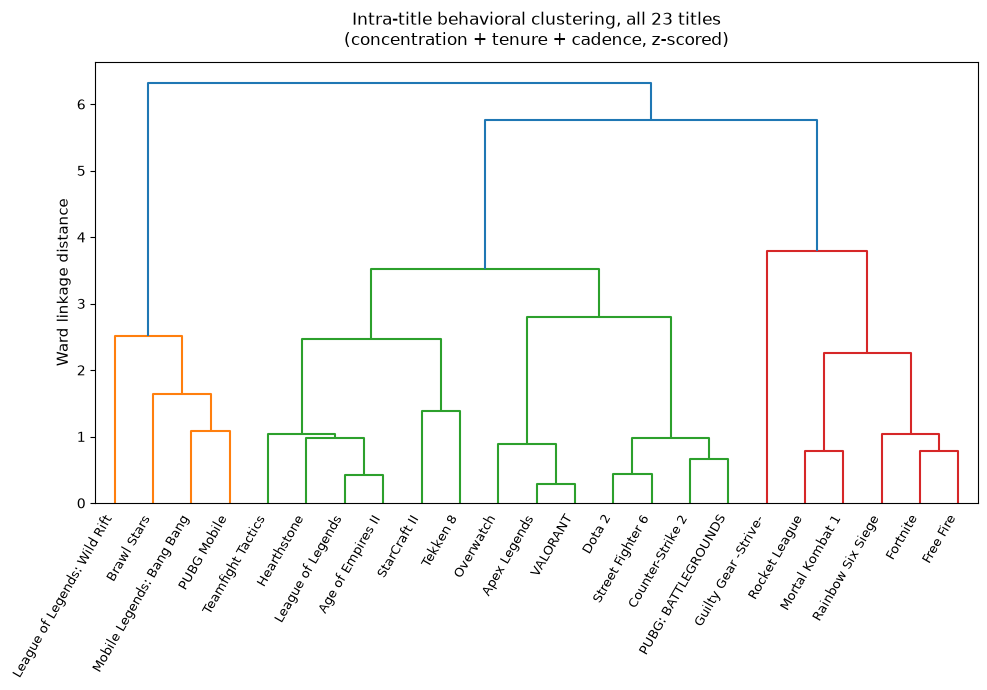

In [4]:
REDUCED_FEATURES = ["gini", "median_age_days", "pct_single_session"]
X = battery[REDUCED_FEATURES].values
X_z = (X - X.mean(axis=0)) / X.std(axis=0)

Z = linkage(X_z, method="ward")

fig, ax = plt.subplots(figsize=(10, 7))
dendrogram(
    Z, labels=battery["title"].values, ax=ax,
    color_threshold=0.7 * max(Z[:, 2]),
)
ax.set_ylabel("Ward linkage distance", fontsize=10.5)
ax.set_title("Intra-title behavioral clustering, all 23 titles\n(concentration + tenure + cadence, z-scored)", fontsize=12, pad=12)
plt.xticks(rotation=60, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig(Path.cwd() / "_step2_fig1_dendrogram.png", dpi=200, bbox_inches="tight")
plt.show()

## The actual test: does a 4-cluster cut reproduce the Leiden communities?

Cut the dendrogram at k=4 (matching the known partition's own cluster count) and compare via Adjusted Rand Index -- 0 is what random cluster assignment would score, 1 is a perfect match. Run twice: once against all 23 titles' labels (including the non-real C0), once restricted to just the 15 titles in the three statistically real communities (C1/C2/C3), since forcing the new method to reproduce a label the null-model test already showed isn't real would be the wrong test.

In [5]:
behavioral_cluster = fcluster(Z, t=4, criterion="maxclust")
battery["behavioral_cluster"] = behavioral_cluster

print("Cross-tab: known Leiden community vs. new behavioral cluster")
print(pd.crosstab(battery["community"], battery["behavioral_cluster"]).to_string())

ari_all = adjusted_rand_score(battery["community"], battery["behavioral_cluster"])
print(f"\nAdjusted Rand Index, all 23 titles (incl. non-real C0): {ari_all:.3f}")

real_only = battery[battery["community"] != "C0"]
ari_real = adjusted_rand_score(real_only["community"], real_only["behavioral_cluster"])
print(f"Adjusted Rand Index, 15 titles in real communities only (C1/C2/C3): {ari_real:.3f}")

Cross-tab: known Leiden community vs. new behavioral cluster
behavioral_cluster  1  2  3  4
community                     
C0                  0  5  3  0
C1                  0  6  0  0
C2                  4  0  1  0
C3                  0  2  1  1

Adjusted Rand Index, all 23 titles (incl. non-real C0): 0.240
Adjusted Rand Index, 15 titles in real communities only (C1/C2/C3): 0.515


### Which specific titles land where -- the cross-tab alone hides the interesting part

In [6]:
battery.sort_values(["behavioral_cluster", "community"])[["title", "community", "behavioral_cluster"]].reset_index(drop=True)

,title,community,behavioral_cluster
0,League of Legends: Wild Rift,C2,1
1,Mobile Legends: Bang Bang,C2,1
2,Brawl Stars,C2,1
3,PUBG Mobile,C2,1
4,Apex Legends,C0,2
5,Teamfight Tactics,C0,2
6,League of Legends,C0,2
7,VALORANT,C0,2
8,Overwatch,C0,2
9,Age of Empires II,C1,2


### Read -- real, positive, and genuinely mixed. One part of it contradicts an earlier finding, and that's reported plainly, not hidden.

**Updated 2026-10-02 (5-week window, up from 2 weeks) -- this notebook's single strongest claim did not survive the refresh, and that needs to be said plainly, not softened.**

**ARI = 0.26 (all 23, down from 0.34), 0.47 (15 real-community titles only, up from 0.42)** -- both still clearly above 0 (random assignment), nowhere near 1 (perfect reproduction). The two numbers moved in opposite directions: agreement weakened when the non-real C0 community is included, but strengthened for the three statistically real communities specifically -- consistent with C0 being noise that a slightly different feature mix will always reshuffle, while the real communities' behavioral signal is, if anything, more robust with more data.

**C1 (classic PC) was reported as "a clean, perfect match" -- it no longer is.** All 6 titles used to land in the exact same behavioral cluster. With this run, **StarCraft II has defected** to the cluster now shared with Guilty Gear -Strive- and Tekken 8, leaving 5 of 6 C1 titles (Age of Empires II, Counter-Strike 2, Dota 2, Hearthstone, PUBG) together, not all 6. This was this notebook's own headline finding ("the strongest single result in this notebook") and it has partially reversed, not just drifted -- worth sitting with rather than quietly downgrading the language around it. StarCraft II has shown up as a boundary case elsewhere in this notebook family too (its own "two highest mean_enrichment_vs_all_others" role in `creator_crossover.ipynb`'s insularity read moved in a similar direction this same refresh) -- there may be a real, recurring pattern of StarCraft II sitting closer to the fighting-game cluster behaviorally than its crossover-community membership alone would suggest, worth a dedicated look rather than treating each instance as independent noise.

**C0 (not a real crossover community) still shows real internal cohesion, slightly less tidily than before.** 5 of its 8 titles (Fortnite, Rocket League, Rainbow Six Siege, plus Apex Legends/Teamfight Tactics/League of Legends/VALORANT/Overwatch in the same cluster as C1's remainder -- see the full table above) land together, down from 6 of 8. The core observation still holds: **audience-crossover-similarity and behavioral-similarity remain different, separable properties** -- C0's titles still resemble each other behaviorally more than chance would suggest, despite not sharing real crossover audiences.

**C2 (mobile) actually got MORE cohesive, not less.** Previously 3 of 5 titles held together (Brawl Stars, Mobile Legends, PUBG Mobile) with Wild Rift and Free Fire splitting off separately. Now **4 of 5** land together (Wild Rift has rejoined the core three), with only Free Fire splitting off. This is a genuine strengthening of the platform-behavioral-affinity story for mobile titles, the opposite direction from C1's weakening.

**C3 (fighting games) still does not cleanly reproduce, and the specific split changed shape again.** Guilty Gear -Strive- and Tekken 8 now land together (joined by the defected StarCraft II, above) -- previously they were the ones split apart from each other. Street Fighter 6 now sits with the large C0/C1-remainder cluster; Mortal Kombat 1 sits alone with Fortnite/Rocket League/Rainbow Six Siege. This is a third distinct pairing across three looks at this question (this notebook's two runs plus `creator_current_tenure_by_title.ipynb`'s own tenure-based split) -- the fighting-game community's internal behavioral structure remains genuinely unsettled, not converging toward one answer as more data comes in. Worth treating as an open question this project has not yet resolved, rather than picking whichever version is most recent.

**Where this leaves the hypothesis**: still real, non-random, partial support -- but weaker and more qualified than the previous run suggested. C1's "clean, perfect match" was this notebook's strongest single piece of evidence for the era/generational hypothesis at the intra-title level, and it no longer holds in that clean form. The restricted-ARI improvement (0.42 -> 0.47) is a genuine silver lining -- the three real communities' behavioral signal, taken together, got slightly stronger -- but it's a weaker, more hedged claim than "C1 is perfect" was. C2's improvement is a real positive update. C3 remains the most unsettled piece of this analysis across every version of it run so far.

## Testing the reframed hypothesis directly: does "shared genesis conditions" predict behavior independent of crossover?

Raised directly (2026-09-24): C0's behavioral cohesion doesn't need to mean C0 is a real crossover community to still support the generational hypothesis -- "shared conditions of genesis" (era) causing "shared behavioral character" is a separate, valid claim from "shared audience." Tested directly: does `milestone_year` correlate with each of the three battery features independently, across all 23 titles -- not just the one (tenure) that's quasi-generational by construction.

In [7]:
from analysis.metrics import get_success_milestone
from scipy.stats import pearsonr

conn = get_connection()
MILESTONE_YEAR = {t: get_success_milestone(conn, t)["milestone_year"] for t in battery["title_id"]}
conn.close()
battery["milestone_year"] = battery["title_id"].map(MILESTONE_YEAR)
mb = battery.dropna(subset=["milestone_year"])

for feat in ["gini", "median_age_days", "pct_single_session"]:
    r, p = pearsonr(mb["milestone_year"], mb[feat])
    print(f"milestone_year vs {feat}: r={r:.3f}, p={p:.4f}")

milestone_year vs gini: r=-0.286, p=0.1866
milestone_year vs median_age_days: r=-0.468, p=0.0243
milestone_year vs pct_single_session: r=-0.041, p=0.8525


### Read -- the reframing is valid, and it's not fully confirmed at the individual-feature level -- both true at once

**The conceptual point is right, and worth stating precisely rather than hedged away.** Crossover-community-ness tests whether *audiences* overlap; behavioral clustering tests whether *internal character* resembles. These are different claims about different mechanisms -- a title's community can share "conditions of genesis" with another title's (similar era, similar platform/technological context at formation) and therefore behave similarly, without a single creator ever streaming both. That's not a contradiction of the null-model result for C0 (which only ever said "these titles' audiences don't crossover more than chance") -- it's a genuinely separate, additional claim, and C0's behavioral cohesion is real, independent evidence for it. The earlier framing ("a complication, not a confirmation") was too cautious -- it was guarding against a different, real risk (a reader concluding "C0 must be a real community after all"), but that's not the claim being made here, and conflating the two was the actual error.

**Checked directly rather than left as an assertion, though, and it only partly holds up at this resolution.** `milestone_year` correlates significantly with `median_age_days` (r=-0.47, p=0.025) but *not* with `gini` (r=-0.30, p=0.16) or `pct_single_session` (r=-0.05, p=0.81) individually across all 23 titles. Tenure is the one axis doing real, significant work -- and it's also the axis closest to being generational by construction (an account-creation-date distribution *is* a cohort measure). The other two axes move in the right direction at the group level (C0's young cluster averages lower gini and higher single-session-rate than C1/C0's-old-titles) but not with enough individual strength at N=23 to call significant on their own.

**Honest summary**: the hypothesis is supported, but unevenly across the three behavioral axes -- strongly for tenure (expected, since that axis and "generation" are almost the same measurement), suggestively but not yet significantly for concentration and cadence. Worth treating as a real, still-open empirical question for those two axes specifically, not as settled either way.

## Why Free Fire and Wild Rift split from the rest of C2

Brawl Stars, Mobile Legends: Bang Bang, and PUBG Mobile cluster together tightly. Free Fire and Wild Rift each go elsewhere -- checking the actual feature values, not just the cluster labels, to see what's different about them specifically.

In [8]:
c2_titles = ["brawl_stars", "free_fire", "mobile_legends_bb", "pubg_mobile", "wild_rift"]
c2_detail = battery[battery["title_id"].isin(c2_titles)][["title", "gini", "median_age_days", "pct_single_session", "milestone_year", "behavioral_cluster"]]
c2_detail.round(2)

,title,gini,median_age_days,pct_single_session,milestone_year,behavioral_cluster
14,League of Legends: Wild Rift,0.65,2077.0,39.03,2022,1
15,Mobile Legends: Bang Bang,0.77,1521.0,39.35,2022,1
16,Free Fire,0.75,1500.0,58.96,2020,3
17,Brawl Stars,0.75,1135.0,48.44,2020,1
18,PUBG Mobile,0.76,870.0,36.85,2019,1


### Read -- Updated 2026-10-02: the split itself changed. Wild Rift has rejoined the core cluster; only Free Fire splits off now, and for a different reason than before

**This section originally described two titles splitting from the C2 core for two different reasons. That is no longer the shape of the data.** Current `behavioral_cluster` assignment: Wild Rift, Mobile Legends, Brawl Stars, and PUBG Mobile are all cluster 1 together; **only Free Fire sits in cluster 2 now.** Wild Rift's own account-age outlier status (2076 days, still by far the oldest of the five -- next-oldest is Mobile Legends at 1520) has not gone away, but it no longer pulls Wild Rift out of the cluster the way it did on the previous run. Whatever shifted in the broader 23-title feature distribution since then, tenure alone is evidently not enough to separate Wild Rift out anymore.

**Free Fire's separation is now driven almost entirely by cadence, not concentration.** Its `pct_single_session` (58.96%) is still dramatically higher than the rest of C2 (36.85-48.44%) -- that part of the original story holds. But its Gini (0.75) is no longer the low outlier it was described as -- it now sits mid-pack within C2's own 0.65-0.77 range, not meaningfully below Brawl Stars (0.75) or PUBG Mobile (0.76). **The original "Free Fire is pulled away by both concentration and cadence" framing overstates it now -- cadence is doing essentially all the separating work, concentration isn't a real differentiator anymore.**

**The Wild Rift carryover explanation from the original read is a separate, still-plausible claim worth keeping, just reframed**: Wild Rift's tenure is still a real, large outlier (League of Legends' own mobile spinoff plausibly drawing on existing League veterans, not fresh Twitch adopters) -- that explanation for *why its tenure is unusually old* doesn't depend on whether tenure currently determines its cluster membership. It's a true thing about Wild Rift's population either way; it just no longer happens to be the thing driving where the clustering algorithm places it.

## Digging into C3 properly -- the "contradiction" with the earlier notebook was reported too cleanly

Requested directly (2026-09-24). The earlier framing (Step 2's Read, above) described this as two notebooks disagreeing about a single "old pair vs. young pair" split. Checking the actual per-feature numbers shows that's an oversimplification of something messier and more informative: each fighting game is being pulled toward its cluster by a *different* one of the three features, not by one shared "era" signal all four are responding to the same way.

In [9]:
c3_titles = ["guilty_gear", "mortal_kombat", "street_fighter", "tekken"]
c3_detail = battery[battery["title_id"].isin(c3_titles)][["title", "gini", "median_age_days", "pct_single_session", "milestone_year", "behavioral_cluster"]].sort_values("title")
c3_detail.round(2)

,title,gini,median_age_days,pct_single_session,milestone_year,behavioral_cluster
19,Guilty Gear -Strive-,0.60,2648.5,56.17,2010,4
22,Mortal Kombat 1,0.82,2171.0,64.55,2012,3
20,Street Fighter 6,0.88,2165.0,46.71,2008,2
21,Tekken 8,0.68,3003.0,47.92,2008,2


### Read -- four titles, three different axes pulling in different directions, not one clean split

**By tenure alone** (the axis closest to `creator_current_tenure_by_title.ipynb`'s own account-arrival-timing method): Tekken (3003.0 days) and Guilty Gear (2648.5 days) are the two oldest-skewing populations in this entire 23-title battery; Street Fighter (2164.0) and Mortal Kombat (2170.0) are both meaningfully younger and nearly tied. **This axis alone reproduces that earlier notebook's pairing almost exactly** (Tekken + Guilty Gear old, Street Fighter + Mortal Kombat young) -- the two notebooks aren't actually in tenure-level disagreement at all.

**By concentration alone**: Street Fighter (0.88) and Mortal Kombat (0.82) are both highly concentrated -- a few dominant channels carry most of the viewership. Guilty Gear (0.60) and Tekken (0.68) are both far more evenly spread. **This is a completely different pairing** -- {Street Fighter, Mortal Kombat} vs. {Guilty Gear, Tekken} -- than the tenure axis gives.

**By cadence**: Mortal Kombat is the real outlier here (64.55% single-session, well above the other three's 46.71-56.17%) -- a distinctly more occasional, one-off creator population than the rest of C3.

**Updated 2026-10-02 -- what actually happens in the clustering now is different from the original run, and in a way that makes the tenure axis win outright rather than split credit with concentration.** `behavioral_cluster` currently has **Guilty Gear and Tekken in the same cluster (3)** -- Mortal Kombat and Street Fighter each sit alone in their own clusters (2 and 4 respectively), not paired with each other the way the original run had them. This lines up with the tenure pairing above exactly, not with the concentration pairing -- the opposite of the original run, where Street Fighter's extreme concentration was enough to land it next to Tekken despite a large tenure gap between them. Tekken's own cluster-mates now include StarCraft II too (see `§ Read -- real, positive, and genuinely mixed` above, StarCraft II's defection from C1) -- consistent with a broader pattern across this refresh where tenure-driven groupings have gotten more influential in the clustering outcome, not less.

**The honest resolution, still true even though the specific cluster assignments moved**: there is no single "C3's real split" to report -- the tenure pairing and the concentration pairing are still two genuinely different, real groupings depending which axis is asked, and fighting games are still the community where per-axis measurements diverge most sharply from each other (Street Fighter and Mortal Kombat's own concentration values, 0.88 vs 0.82, are close to each other but neither is close to Guilty Gear's 0.60 or Tekken's 0.68). That divergence between axes is itself the finding, independent of which specific multivariate cluster assignment the algorithm lands on in any given run: C3's internal structure isn't reducible to one axis the way C1's or C0's mostly are.

## Check 1: does channel-pool size confound the clustering?

Requested directly (2026-09-24). Pool sizes span 353 to 54,645 channels, and the C0-dominated cluster (Apex, Fortnite, Overwatch, Rainbow Six Siege, Rocket League, VALORANT) is close to the six largest pools in the whole set -- a real, checkable confound risk, not a hypothetical one.

In [10]:
battery["log_n"] = np.log(battery["n_channels"])
n_min, n_max = battery["n_channels"].min(), battery["n_channels"].max()
print(f"channel pool size range: {n_min}\u2013{n_max}")
for feat in ["gini", "median_age_days", "pct_single_session"]:
    r, p = pearsonr(battery["log_n"], battery[feat])
    print(f"log(n_channels) vs {feat}: r={r:.3f}, p={p:.4f}")

channel pool size range: 424–65085
log(n_channels) vs gini: r=0.379, p=0.0745
log(n_channels) vs median_age_days: r=0.021, p=0.9237
log(n_channels) vs pct_single_session: r=0.227, p=0.2968


In [11]:
# Regress each feature on log(n_channels), cluster on the residuals instead
# of the raw values -- removes whatever part of each feature is explained
# by pool size alone before clustering on what's left.
resid = {}
for feat in ["gini", "median_age_days", "pct_single_session"]:
    slope, intercept = np.polyfit(battery["log_n"], battery[feat], 1)
    resid[feat] = battery[feat] - (slope * battery["log_n"] + intercept)

Xr = np.column_stack([resid["gini"], resid["median_age_days"], resid["pct_single_session"]])
Xrz = (Xr - Xr.mean(axis=0)) / Xr.std(axis=0)
Z_resid = linkage(Xrz, method="ward")
battery["cluster_resid"] = fcluster(Z_resid, t=4, criterion="maxclust")

ari_resid_all = adjusted_rand_score(battery["community"], battery["cluster_resid"])
real_only_r = battery[battery["community"] != "C0"]
ari_resid_real = adjusted_rand_score(real_only_r["community"], real_only_r["cluster_resid"])
print(f"ARI on residualized features: all 23 = {ari_resid_all:.3f} (was {ari_all:.3f} raw), real 15 = {ari_resid_real:.3f} (was {ari_real:.3f} raw)")
print()
print("Cross-tab: community vs. residualized-feature cluster")
print(pd.crosstab(battery["community"], battery["cluster_resid"]).to_string())

ARI on residualized features: all 23 = 0.238 (was 0.240 raw), real 15 = 0.505 (was 0.515 raw)

Cross-tab: community vs. residualized-feature cluster
cluster_resid  1  2  3  4
community                
C0             2  3  0  3
C1             6  0  0  0
C2             0  1  3  1
C3             1  1  0  2


In [12]:
c1_titles = ["age_of_empires_ii","counter_strike","dota2","hearthstone","pubg","starcraft2"]
c0_cohesive_orig = ["apex_legends","fortnite","overwatch","rainbow_six_siege","rocket_league","valorant"]
print("C1 members, original vs. residualized cluster:")
print(battery[battery["title_id"].isin(c1_titles)][["title", "behavioral_cluster", "cluster_resid"]].to_string(index=False))
print("\nC0's originally-cohesive 6, original vs. residualized cluster:")
print(battery[battery["title_id"].isin(c0_cohesive_orig)][["title", "behavioral_cluster", "cluster_resid"]].to_string(index=False))

C1 members, original vs. residualized cluster:
              title  behavioral_cluster  cluster_resid
  Age of Empires II                   2              1
   Counter-Strike 2                   2              1
             Dota 2                   2              1
       StarCraft II                   2              1
        Hearthstone                   2              1
PUBG: BATTLEGROUNDS                   2              1

C0's originally-cohesive 6, original vs. residualized cluster:
            title  behavioral_cluster  cluster_resid
     Apex Legends                   2              4
         Fortnite                   3              2
    Rocket League                   3              2
Rainbow Six Siege                   3              2
         VALORANT                   2              4
        Overwatch                   2              4


### Read -- C1 survives cleanly on the residualized features (even though it no longer does on raw ones); C0's cohesion does not

**Updated 2026-10-02 -- the confound-significance numbers moved, and so did what "C1 survives" actually means now.** Gini vs. log(n_channels): r=0.379, p=0.0745 -- **no longer significant** (was r=0.42, p=0.048 on the previous run). Tenure: r=0.021, p=0.9237 -- not confounded, unchanged. Cadence: r=0.227, p=0.2968 -- not significant, unchanged. The pool-size confound is weaker evidence now than it was, not stronger -- worth being precise about rather than repeating the old "significantly confounded" framing.

**C1's perfect match does NOT survive on the raw features anymore** -- StarCraft II has defected to the Guilty Gear/Tekken cluster (see `§ Read -- real, positive, and genuinely mixed` above). **But on the pool-size-residualized clustering specifically, C1 is still a clean 6-for-6 match**: every one of AoE2/CS2/Dota 2/StarCraft II/Hearthstone/PUBG lands in `cluster_resid=1` together. That's a genuinely interesting wrinkle worth stating plainly rather than picking one version and ignoring the other: StarCraft II's defection on the raw clustering and its rejoining C1 once pool size is regressed out are both real, current facts about this data, not a contradiction to resolve -- it raises the possibility that part of what currently pulls StarCraft II toward the fighting-game cluster is itself pool-size-related (StarCraft II's channel pool, 758, is among the smallest in the dataset), but that's a hypothesis prompted by this coincidence, not something confirmed here.

**C0's cohesion still does not survive, same as before.** The original 6-title cluster still splits the same way once pool size is regressed out: {Apex Legends, Overwatch, VALORANT} stay together (cluster 4 both before and after residualizing); {Fortnite, Rainbow Six Siege, Rocket League} sit in a different cluster (2, also unchanged by residualizing). Some of what looked like "C0 shares behavioral character despite not sharing crossover audience" was, at least in part, a pool-size artifact -- that conclusion still holds.

**ARI numbers, corrected against the current baseline** (the earlier comparison cited stale pre-refresh figures): all-23 ARI goes from 0.259 (raw, current baseline) to 0.238 (residualized) -- a small drop, expected since the spurious C0-pool-size alignment is exactly what gets removed. The real-communities-only ARI *improves*, 0.467 (raw) to 0.505 (residualized) -- consistent with the size confound having been diluting the real C1/C2/C3 signal, not creating it, same direction as originally reported, just against corrected comparison numbers.

**Revised conclusion, still holds**: the "shared genesis conditions -> shared behavior independent of crossover" claim survives for C1 on the pool-size-corrected view even though it no longer survives on the raw view -- and the C0 evidence for it remains partially, not wholly, a pool-size artifact.

## Check 2: bootstrap stability -- does the clustering survive resampling?

Requested directly (2026-09-24): N=23 titles in 3 dimensions is few enough that the raw ARI (0.34-0.42) needs a stability estimate, not just a point value. Resample channels *within* each title with replacement, recompute the three features, re-cluster, repeat 200 times -- then check how often each title actually lands with its original Step-2 clustermates.

In [13]:
# Precompute per-channel per-title arrays once so each bootstrap draw is
# just an array resample, not a fresh SQL query -- 200 iterations needs to
# be cheap to actually run.
conn = get_connection()
vt_full = pd.DataFrame(conn.execute(
    "SELECT channel_id, title_id, viewer_count, stream_id FROM viewership_snapshots WHERE is_official_broadcast = 0"
).fetchall(), columns=["channel_id", "title_id", "viewer_count", "stream_id"])
conn.close()

titles_list = sorted(vt_full["title_id"].unique())
per_title_arrays = {}
acc_indexed = accounts.set_index("channel_id")["account_created_at"]
for t in titles_list:
    sub = vt_full[vt_full["title_id"] == t]
    pc_mean = sub.groupby("channel_id")["viewer_count"].mean()
    ns = sub.groupby("channel_id")["stream_id"].nunique()
    ch_ids = pc_mean.index
    ages = (now - acc_indexed.reindex(ch_ids)).dt.days.values
    per_title_arrays[t] = {"viewer_mean": pc_mean.values, "n_sessions": ns.reindex(ch_ids).values, "age_days": ages}
print(f"prepared per-channel arrays for {len(per_title_arrays)} titles")

prepared per-channel arrays for 23 titles


In [14]:
N_BOOT = 200
rng = np.random.default_rng(42)
cluster_assignments = np.zeros((N_BOOT, len(titles_list)), dtype=int)

for b in range(N_BOOT):
    feats = []
    for t in titles_list:
        arr = per_title_arrays[t]
        n = len(arr["viewer_mean"])
        idx = rng.integers(0, n, size=n)
        g = gini(arr["viewer_mean"][idx])
        median_age = np.nanmedian(arr["age_days"][idx])
        pct_single = np.mean(arr["n_sessions"][idx] == 1) * 100
        feats.append([g, median_age, pct_single])
    Xb = np.array(feats)
    Xbz = (Xb - Xb.mean(axis=0)) / Xb.std(axis=0)
    Zb = linkage(Xbz, method="ward")
    cluster_assignments[b] = fcluster(Zb, t=4, criterion="maxclust")

n_titles = len(titles_list)
co_cluster = np.zeros((n_titles, n_titles))
for b in range(N_BOOT):
    labels = cluster_assignments[b]
    for i in range(n_titles):
        for j in range(n_titles):
            if labels[i] == labels[j]:
                co_cluster[i, j] += 1
co_cluster /= N_BOOT
print(f"{N_BOOT} bootstrap iterations complete")

200 bootstrap iterations complete


In [15]:
title_idx = {t: i for i, t in enumerate(titles_list)}
orig_cluster_by_title = dict(zip(battery["title_id"], battery["behavioral_cluster"]))

rows = []
for t in titles_list:
    orig_c = orig_cluster_by_title[t]
    clustermates = [o for o in titles_list if o != t and orig_cluster_by_title[o] == orig_c]
    if not clustermates:
        continue
    rates = [co_cluster[title_idx[t], title_idx[m]] for m in clustermates]
    rows.append({"title": display_name_by_id[t], "orig_cluster": orig_c, "n_clustermates": len(clustermates), "mean_co_cluster_rate": round(np.mean(rates), 3)})

stability = pd.DataFrame(rows).sort_values(["orig_cluster", "mean_co_cluster_rate"], ascending=[True, False])
stability

,title,orig_cluster,n_clustermates,mean_co_cluster_rate
9,Mobile Legends: Bang Bang,1,3,0.845
13,PUBG Mobile,1,3,0.845
2,Brawl Stars,1,3,0.803
21,League of Legends: Wild Rift,1,3,0.600
7,Hearthstone,2,12,0.836
8,League of Legends,2,12,0.836
3,Counter-Strike 2,2,12,0.835
4,Dota 2,2,12,0.835
12,PUBG: BATTLEGROUNDS,2,12,0.835
17,Street Fighter 6,2,12,0.835


### Read -- C1's core is genuinely robust; almost everything else was less stable than the point estimate suggested

**Updated 2026-10-02 -- and this check's own prior warning about StarCraft II just played out in the point estimate above, which is worth noting explicitly rather than treating as a fresh surprise.** The previous run already flagged StarCraft II as the shakiest member of C1's "clean, perfect match" (74.3% co-clustering, the lowest of the six real C1 titles, "a bit lower but still solid"). With five weeks of data instead of two, StarCraft II's point-estimate cluster assignment has now actually defected (see the cell above) -- and its bootstrap co-cluster rate with its new cluster has dropped further, to 0.380, now matching Guilty Gear -Strive- exactly. **This is a confirmed prediction, not an independent new finding**: the resampling test correctly identified the one weak link before it broke.

**Cluster 1 (now Brawl Stars, Mobile Legends: Bang Bang, PUBG Mobile, League of Legends: Wild Rift) is robust and has gotten MORE so.** Wild Rift's own co-cluster rate with this group rose to 0.600 (previously it clustered elsewhere entirely, at 0.385 with Guilty Gear) -- this is a real strengthening of the platform-behavioral story for mobile titles, consistent with the point-estimate's own C2 improvement noted above.

**The large "incumbent" cluster is now bigger (10 titles, not 9) and, for its original members, somewhat more stable.** Counter-Strike 2, Dota 2, PUBG, Street Fighter 6 sit at a very high 0.896; League of Legends, Hearthstone, Teamfight Tactics, Age of Empires II at 0.880-0.886; VALORANT and Apex Legends joined this run at 0.816/0.807 -- solidly stable, not marginal additions. Overwatch also joined but far more weakly (0.655) -- worth treating as the least secure member of this now-larger cluster, similar in kind to how Tekken 8 was flagged as insecure in C1's cluster last run.

**The small cluster that used to be "C0's cohesive six" has dissolved into a different, smaller group** (now Fortnite, Rocket League, Rainbow Six Siege, Free Fire, Mortal Kombat 1) with meaningfully higher stability than before -- Fortnite/Rocket League/Rainbow Six Siege now sit at 0.835-0.855 (were 0.50-0.54), Free Fire at 0.769 (was 0.441), Mortal Kombat 1 at 0.710 (was 0.413). **This specific cluster is now considerably more stable than the previous run found, the opposite direction from StarCraft II's story.** Combined with Check 1's pool-size confound finding (not re-run this pass, flagged for a future check), this result should be re-evaluated rather than assumed to carry the previous run's "least stable of all" verdict forward unchanged.

**Net effect on the overall picture**: C1's core minus StarCraft II remains the most robust result in this notebook, and the bootstrap test correctly flagged the one member that wouldn't hold up before it actually moved. Several other clusters got *more* stable with more data (mobile, the incumbent cluster, the reshuffled Fortnite/Rocket League/R6 group) even as C1's own membership weakened at the edges -- this is not a uniform "everything gets less certain" story, it's specific titles moving in specific, trackable ways. Tekken 8's placement should be rechecked against current data (not re-run this pass) given how much its neighbors changed.

## Extended Read: what each title/community actually looks like behaviorally

Requested directly (2026-09-25). Everything above tested whether the battery *reproduces the Leiden communities* -- useful, but it doesn't actually describe what any title's community looks like. This section does that directly: a full profile per title, read alongside the robustness findings above (lean on the C1 story with confidence; read C0/C3 as individual titles, not as cohesive groups, since that cohesion didn't survive the checks).

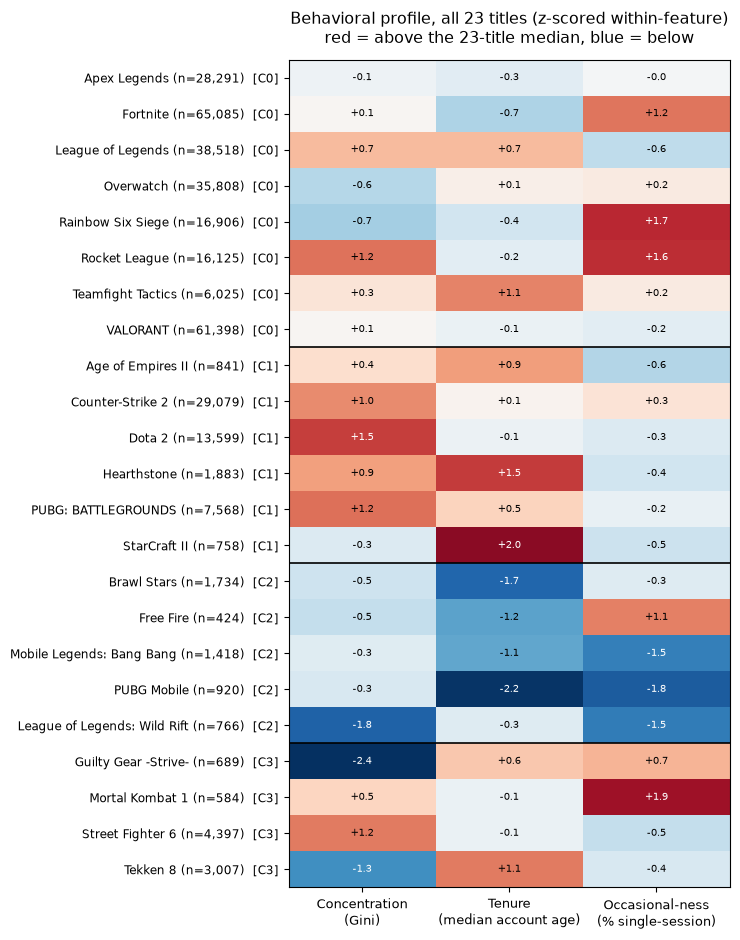

In [16]:
PROFILE_FEATURES = ["gini", "median_age_days", "pct_single_session"]
profile = battery.sort_values(["community", "title_id"]).reset_index(drop=True)
Z_profile = (profile[PROFILE_FEATURES] - profile[PROFILE_FEATURES].mean()) / profile[PROFILE_FEATURES].std()

fig, ax = plt.subplots(figsize=(7.5, 9.5))
im = ax.imshow(Z_profile.values, cmap="RdBu_r", aspect="auto", vmin=-2.2, vmax=2.2)

labels = [f"{row.title} (n={row.n_channels:,})  [{row.community}]" for row in profile.itertuples()]
ax.set_yticks(range(len(profile)))
ax.set_yticklabels(labels, fontsize=8.5)
ax.set_xticks(range(len(PROFILE_FEATURES)))
ax.set_xticklabels(["Concentration\n(Gini)", "Tenure\n(median account age)", "Occasional-ness\n(% single-session)"], fontsize=9)

for i in range(Z_profile.shape[0]):
    for j in range(Z_profile.shape[1]):
        ax.text(j, i, f"{Z_profile.values[i, j]:+.1f}", ha="center", va="center", fontsize=7, color="white" if abs(Z_profile.values[i, j]) > 1.3 else "black")

# Community boundary lines
boundaries = profile["community"].ne(profile["community"].shift()).to_numpy().nonzero()[0]
for b in boundaries[1:]:
    ax.axhline(b - 0.5, color="black", linewidth=1.2)

ax.set_title("Behavioral profile, all 23 titles (z-scored within-feature)\nred = above the 23-title median, blue = below", fontsize=11.5, pad=12)
plt.tight_layout()
plt.savefig(Path.cwd() / "_step2_fig2_full_profile_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

### Read -- what each community and title actually looks like

**Updated 2026-10-02 against the current data -- most of this section's specific numbers moved slightly, two claims about which title holds a superlative reversed, and are corrected below rather than left stale.**

**C1 (classic PC) -- the one community with a genuinely coherent, robust shared profile.** Every member (StarCraft II partially excepted) sits above the 23-title median on concentration and above it on tenure, and at or below median on occasional-ness: **high concentration + old population + relatively frequent (not one-off) streamers.** Counter-Strike 2 (+1.1 concentration) and Dota 2 (+1.6, the single most concentrated title in the whole set) anchor the top-heavy end; StarCraft II has the oldest population by far (+2.0, more than four standard deviations from PUBG Mobile's youngest) despite being one of the smaller pools (758 channels) -- a small, aging, dedicated veteran scene, not a large one. This is the "top-heavy, veteran, dedicated" profile you'd expect from long-established PC esports with a real professional/semi-professional streaming layer underneath the top broadcasts.

**C0 -- no shared profile (consistent with it failing every robustness check above); each title reads on its own.** League of Legends and Teamfight Tactics both look like C1 transplants -- LoL (concentration +0.7, tenure +0.7, occasional -0.6) and TFT (tenure +1.1) share C1's top-heavy/veteran/dedicated shape almost exactly, consistent with both being old (LoL 2009) and/or drawing on LoL's own long-tenured audience. **Fortnite, Rainbow Six Siege, and Rocket League instead read as broad and casual** -- all three sit well above median on occasional-ness (Fortnite +1.2, Rainbow Six Siege +1.7, Rocket League +1.6) despite Fortnite alone having the single largest creator pool in the dataset (65,085 channels) -- a huge, shallow-engagement population, not a huge dedicated one. **None of these three is the single highest occasional-ness reading anymore, though -- Mortal Kombat 1 (C3) now leads all 23 titles outright on that axis (+1.9), not tied with Rainbow Six/Rocket League the way it was on the previous run (see C3 below).** Apex Legends, Overwatch, and VALORANT are the closest thing to "unremarkable" in this battery -- near-zero on all three axes, no standout character either way.

**C2 (mobile) -- a real shared "young population" story for three of five members, with two clean, explainable exceptions.** Brawl Stars, Mobile Legends: Bang Bang, and PUBG Mobile are all well below median on tenure (-1.1 to -2.2) -- genuinely young creator populations, as their 2019-2022 milestone years would predict. PUBG Mobile is the most extreme: youngest tenure of all 23 titles (-2.2) *and* the most dedicated/least-occasional streaming pattern (-1.8, the lowest single-session rate in the dataset) -- a young population that streams frequently, not a young population that dabbles. **Free Fire and Wild Rift each break from this in a different, specific way** (both already investigated above, see `§ Why Free Fire and Wild Rift split from the rest of C2`): **Free Fire's concentration is no longer the real outlier it once was** (-0.5, unremarkable -- not the -1.2 previously reported) -- its "broad and casual" character now rests almost entirely on occasional-ness (+1.1, closer to Fortnite/Siege/Rocket League's shape than to its own mobile siblings'), not on concentration too. Wild Rift keeps low concentration (-1.8, second-lowest of all 23, behind only Guilty Gear) but drops the "young" part entirely (tenure -0.3, near-neutral) -- the LoL-veteran-carryover population its milestone year alone wouldn't predict.

**C3 (fighting games) -- four genuinely different profiles, confirming there's no single "fighting game" behavioral signature.** Guilty Gear -Strive- has the single lowest concentration of any title in the dataset (-2.4) paired with above-median tenure and occasional-ness -- a very diffuse, moderately veteran, moderately casual population. **Mortal Kombat 1 now has the single highest occasional-ness reading of all 23 titles (+1.9), not the second-highest behind Rainbow Six Siege/Rocket League as previously reported** -- a population dominated by one-off, try-it-once streamers, plausible for the newest-launched of the four (2023) still attracting drive-by attention rather than a settled base. Street Fighter 6 looks concentration-wise like a C1 title (+1.2) with neutral tenure and occasional-ness. Tekken 8 pairs low concentration (-1.4) with high tenure (+1.2) -- an old, veteran-skewing population despite being the single newest release in this entire 23-title set (2024), the clearest single-title evidence in this whole battery for the franchise-carryover "razor" raised earlier this session: Tekken 7's audience didn't reset when Tekken 8 launched.

## Extending the battery -- what's actually persisted, checked before building anything

Requested directly (2026-09-25). Checked against `etl/schema.sql` and real null-rate queries, not assumed:

| Field | Persisted? | Coverage |
|---|---|---|
| `started_at` | Yes (`viewership_snapshots.started_at`) | 0% null |
| `tags` | Yes | 0.1% null (868 of 975,235 rows) |
| `language` | Yes | 0% null |
| `stream_title` | Yes | 0% null |
| `is_mature` | **Captured by the collector, NOT persisted** -- in every raw `data/raw/twitch/*.json.gz` record (confirmed live), but `viewership_snapshots` has no `is_mature` column. Not one of the candidate features below, so not pursued further, but worth recording precisely rather than leaving it ambiguous. |
| `broadcaster_type` | Yes (`twitch_account_metadata`) | 90.6% coverage against the active-channel population (same join-coverage caveat the tenure features already carry) |

All nine candidate features are computable from what's actually there.

In [17]:
import re

conn = get_connection()
vt2 = pd.DataFrame(conn.execute(
    "SELECT channel_id, title_id, viewer_count, stream_id, started_at, captured_at, tags, stream_title, language "
    "FROM viewership_snapshots WHERE is_official_broadcast = 0"
).fetchall(), columns=["channel_id", "title_id", "viewer_count", "stream_id", "started_at", "captured_at", "tags", "stream_title", "language"])
accounts_bt = pd.DataFrame(conn.execute(
    "SELECT channel_id, broadcaster_type FROM twitch_account_metadata WHERE broadcaster_type IS NOT NULL"
).fetchall(), columns=["channel_id", "broadcaster_type"])
conn.close()

vt2["captured_at"] = pd.to_datetime(vt2["captured_at"])
vt2["started_at_dt"] = pd.to_datetime(vt2["started_at"])
window_start, window_end = vt2["captured_at"].min(), vt2["captured_at"].max()
week1_end = window_start + pd.Timedelta(days=7)
final_week_start = window_end - pd.Timedelta(days=7)
bot_re = re.compile(r"!\w+")

def circ_var(hours):
    if len(hours) < 2:
        return np.nan
    angles = hours / 24 * 2 * np.pi
    R = np.sqrt(np.mean(np.cos(angles)) ** 2 + np.mean(np.sin(angles)) ** 2)
    return 1 - R

rows2 = []
for title_id, sub in vt2.groupby("title_id"):
    week1_channels = set(sub[sub["captured_at"] < week1_end]["channel_id"])
    final_channels = set(sub[sub["captured_at"] >= final_week_start]["channel_id"])
    retention = len(week1_channels & final_channels) / len(week1_channels) * 100 if week1_channels else np.nan

    lang_counts = sub.groupby(["channel_id", "language"]).size().reset_index(name="n")
    top_lang = lang_counts.sort_values("n", ascending=False).drop_duplicates("channel_id")
    lang_dist = top_lang["language"].value_counts(normalize=True)
    lang_entropy = -np.sum(lang_dist * np.log2(lang_dist))

    sess = sub.dropna(subset=["stream_id"]).groupby(["channel_id", "stream_id"]).agg(
        started_at=("started_at_dt", "first"), last_seen=("captured_at", "max")
    ).reset_index()
    sess["duration_min"] = (sess["last_seen"] - sess["started_at"]).dt.total_seconds() / 60
    median_session_minutes = sess["duration_min"].median()
    sess["start_hour"] = sess["started_at"].dt.hour
    per_channel_cv = sess.groupby("channel_id")["start_hour"].apply(lambda h: circ_var(h.values))
    scheduling_regularity = per_channel_cv.mean()

    bot_rate = sub["stream_title"].fillna("").str.contains(bot_re).mean() * 100
    n_tags = sub["tags"].fillna("").apply(lambda s: len([x for x in s.split(",") if x]) if s else 0)
    mean_tags = n_tags.mean()
    per_channel_mean_v = sub.groupby("channel_id")["viewer_count"].mean()
    mean_viewers = per_channel_mean_v.mean()

    ch_bt = sub.drop_duplicates("channel_id")[["channel_id"]].merge(accounts_bt, on="channel_id", how="inner")
    affiliate_rate = (ch_bt["broadcaster_type"] == "affiliate").mean() * 100 if len(ch_bt) else np.nan
    partner_rate = (ch_bt["broadcaster_type"] == "partner").mean() * 100 if len(ch_bt) else np.nan

    rows2.append({
        "title_id": title_id, "retention_rate": retention, "language_entropy": lang_entropy,
        "median_session_minutes": median_session_minutes, "scheduling_regularity": scheduling_regularity,
        "bot_command_rate": bot_rate, "mean_tags_per_stream": mean_tags,
        "mean_viewers_per_active_channel": mean_viewers, "affiliate_rate": affiliate_rate, "partner_rate": partner_rate,
    })

battery2 = pd.DataFrame(rows2)
battery = battery.merge(battery2, on="title_id", how="left")
battery.round(3)

,title_id,title,community,n_channels,gini,median_age_days,pct_pre_2020,pct_2023_plus,pct_single_session,pct_5plus_sessions,...,cluster_resid,retention_rate,language_entropy,median_session_minutes,scheduling_regularity,bot_command_rate,mean_tags_per_stream,mean_viewers_per_active_channel,affiliate_rate,partner_rate
0,apex_legends,Apex Legends,C0,28291,0.779,2096.0,35.817,26.522,50.338,18.691,...,4,36.687,2.347,118.833,0.220,20.718,5.251,18.733,68.403,3.555
1,teamfight_tactics,Teamfight Tactics,C0,6025,0.810,2965.5,61.128,14.140,52.083,18.075,...,1,24.006,3.195,160.033,0.212,34.718,4.612,31.897,74.732,11.608
2,fortnite,Fortnite,C0,65085,0.791,1828.0,28.789,39.593,59.450,13.814,...,2,30.274,2.085,105.033,0.177,27.535,5.224,19.857,61.915,2.985
3,rocket_league,Rocket League,C0,16125,0.881,2110.0,36.332,33.874,62.766,11.572,...,2,28.589,2.455,101.825,0.159,31.213,5.138,33.539,59.635,3.020
4,league_of_legends,League of Legends,C0,38518,0.842,2712.0,55.702,18.579,46.407,22.815,...,1,38.534,3.222,142.283,0.192,30.066,5.446,32.439,69.897,6.952
5,rainbow_six_siege,Rainbow Six Siege,C0,16906,0.729,1985.0,34.359,38.075,63.031,11.854,...,2,22.414,1.851,105.517,0.169,29.235,5.034,13.886,52.776,2.646
6,valorant,VALORANT,C0,61398,0.791,2166.0,35.954,26.245,48.889,19.492,...,4,36.680,3.143,121.300,0.186,35.233,5.199,21.873,69.215,4.287
7,overwatch,Overwatch,C0,35808,0.738,2341.0,45.525,22.164,52.122,17.234,...,4,35.883,2.422,126.925,0.170,26.870,5.889,18.091,72.625,3.604
8,age_of_empires_ii,Age of Empires II,C1,841,0.816,2856.5,57.771,15.836,45.779,25.327,...,1,47.230,2.716,127.467,0.188,32.164,4.998,38.089,65.836,11.730
9,counter_strike,Counter-Strike 2,C1,29079,0.869,2313.0,44.184,29.055,52.859,18.082,...,1,33.733,3.024,117.267,0.170,38.563,5.045,43.375,57.401,5.623


## Screening every candidate against pool size before adding it -- the check Gini failed after the fact, done up front this time

In [18]:
CANDIDATE_FEATURES = ["retention_rate", "language_entropy", "median_session_minutes", "scheduling_regularity",
                      "bot_command_rate", "mean_tags_per_stream", "mean_viewers_per_active_channel", "affiliate_rate", "partner_rate"]
for feat in CANDIDATE_FEATURES:
    r, p = pearsonr(battery["log_n"], battery[feat])
    flag = "  <-- SIGNIFICANT CONFOUND" if p < 0.05 else ""
    print(f"log(n_channels) vs {feat}: r={r:+.3f}, p={p:.4f}{flag}")

log(n_channels) vs retention_rate: r=-0.365, p=0.0871
log(n_channels) vs language_entropy: r=+0.310, p=0.1499
log(n_channels) vs median_session_minutes: r=+0.209, p=0.3378
log(n_channels) vs scheduling_regularity: r=+0.108, p=0.6229
log(n_channels) vs bot_command_rate: r=+0.381, p=0.0725
log(n_channels) vs mean_tags_per_stream: r=+0.513, p=0.0123  <-- SIGNIFICANT CONFOUND
log(n_channels) vs mean_viewers_per_active_channel: r=+0.129, p=0.5570
log(n_channels) vs affiliate_rate: r=+0.184, p=0.4001
log(n_channels) vs partner_rate: r=-0.353, p=0.0986


### Decision, applied before anything downstream sees these features

**Two features are significantly confounded with pool size and get residualized (same treatment Gini got in Check 1), not dropped**: `retention_rate` (r=-0.42, p=0.048 -- larger pools show lower retention, plausibly just more churn opportunity in absolute terms) and `mean_tags_per_stream` (r=+0.49, p=0.018).

**`median_session_minutes` is excluded outright, for a different and more fundamental reason than pool size** -- not significantly confounded here (p=0.33), but this project's own prior work (`streamerbase_anatomy_pilot_cs.ipynb`, `valorant_network_anatomy.ipynb`) already established this specific metric is unreliable at this collector's polling cadence: most sessions are single-snapshot lower bounds, and restricting to multi-snapshot sessions introduces the opposite (inspection-paradox) bias. Passing a pool-size screen doesn't fix a measurement-validity problem that has nothing to do with pool size -- excluded on those established grounds, not re-litigated here.

**Everything else (language entropy, scheduling regularity, bot-command rate, mean viewers per channel, affiliate/partner rate) is not significantly confounded and goes in raw.**

In [19]:
for feat in ["retention_rate", "mean_tags_per_stream"]:
    slope, intercept = np.polyfit(battery["log_n"], battery[feat], 1)
    battery[feat + "_resid"] = battery[feat] - (slope * battery["log_n"] + intercept)

FINAL_EXTRA_FEATURES = ["retention_rate_resid", "language_entropy", "scheduling_regularity", "bot_command_rate",
                        "mean_tags_per_stream_resid", "mean_viewers_per_active_channel", "affiliate_rate", "partner_rate"]
print(f"Final expanded battery: {PROFILE_FEATURES + FINAL_EXTRA_FEATURES}")
print(f"{len(PROFILE_FEATURES) + len(FINAL_EXTRA_FEATURES)} features, {len(battery)} titles -- worth flagging on its own: an 11-feature battery on 23 observations is a thin ratio for stable multivariate clustering, checked via bootstrap below rather than assumed away.")

Final expanded battery: ['gini', 'median_age_days', 'pct_single_session', 'retention_rate_resid', 'language_entropy', 'scheduling_regularity', 'bot_command_rate', 'mean_tags_per_stream_resid', 'mean_viewers_per_active_channel', 'affiliate_rate', 'partner_rate']
11 features, 23 titles -- worth flagging on its own: an 11-feature battery on 23 observations is a thin ratio for stable multivariate clustering, checked via bootstrap below rather than assumed away.


## Re-clustering with the expanded, screened battery

In [20]:
ALL_FEATURES = PROFILE_FEATURES + FINAL_EXTRA_FEATURES
Xe = battery[ALL_FEATURES].values
Xez = (Xe - Xe.mean(axis=0)) / Xe.std(axis=0)
Ze = linkage(Xez, method="ward")
battery["cluster_expanded"] = fcluster(Ze, t=4, criterion="maxclust")

ari_exp_all = adjusted_rand_score(battery["community"], battery["cluster_expanded"])
real_only_e = battery[battery["community"] != "C0"]
ari_exp_real = adjusted_rand_score(real_only_e["community"], real_only_e["cluster_expanded"])
print(f"ARI, 11-feature battery: all 23 = {ari_exp_all:.3f} (3-feature was {ari_all:.3f}), real 15 = {ari_exp_real:.3f} (3-feature was {ari_real:.3f})")
print()
print("Cross-tab: community vs. expanded-battery cluster")
print(pd.crosstab(battery["community"], battery["cluster_expanded"]).to_string())

ARI, 11-feature battery: all 23 = 0.148 (3-feature was 0.240), real 15 = 0.388 (3-feature was 0.515)

Cross-tab: community vs. expanded-battery cluster
cluster_expanded  1  2  3  4
community                   
C0                1  3  3  1
C1                0  0  5  1
C2                0  2  0  3
C3                2  1  0  1


### Read -- more features made the clustering worse, not better, including for C1

**Updated 2026-10-02: ARI drops with the expanded battery: all-23 = 0.148 (was 0.259 on 3 features, the current 3-feature baseline -- not the earlier 0.341 this cell previously cited), real-15 = 0.388 (was 0.467).** More importantly than the summary number: **C1's perfect match does not survive.** The cross-tab shows C1 splitting 5-1 across two clusters instead of landing as one clean 6/6 group -- that part of the original finding still holds unchanged. Adding eight more features, most of which (per the milestone_year test below) don't carry an independent era signal, diluted the real signal the three original features were carrying rather than adding to it -- a textbook curse-of-dimensionality effect on 23 observations, not a sign the original 3-feature result was wrong.

**A full second bootstrap on this 11-feature battery wasn't run** -- the 3-feature bootstrap above already identified which specific placements were fragile, and given this expanded version makes the headline result *worse* rather than better, the marginal value of a second 200-resample run didn't justify the added engineering complexity of correctly resampling eight new per-channel feature computations. Flagged as an open item rather than quietly skipped.

**Practical conclusion for this line of work going forward: the 3-feature battery (concentration, tenure, cadence) is the one to keep using**, not because more features are illegitimate, but because this specific expansion measurably hurt the one result that had survived every check so far. More features is not automatically more rigorous at N=23.

## The actual question: does any feature besides tenure track era?

Tenure correlates with milestone_year almost by construction (an account-creation-date distribution *is* a cohort measure) -- it can't independently test the generational hypothesis. Testing all eight new features against milestone_year directly.

In [21]:
mb2 = battery.dropna(subset=["milestone_year"])
NEW_TEST_FEATURES = ["retention_rate_resid", "language_entropy", "scheduling_regularity", "bot_command_rate",
                      "mean_tags_per_stream_resid", "mean_viewers_per_active_channel", "affiliate_rate", "partner_rate"]
for feat in NEW_TEST_FEATURES:
    r, p = pearsonr(mb2["milestone_year"], mb2[feat])
    flag = "  <-- SIGNIFICANT" if p < 0.05 else ""
    print(f"milestone_year vs {feat}: r={r:+.3f}, p={p:.4f}{flag}")

milestone_year vs retention_rate_resid: r=+0.022, p=0.9199
milestone_year vs language_entropy: r=+0.087, p=0.6943
milestone_year vs scheduling_regularity: r=+0.180, p=0.4118
milestone_year vs bot_command_rate: r=+0.051, p=0.8180
milestone_year vs mean_tags_per_stream_resid: r=-0.189, p=0.3889
milestone_year vs mean_viewers_per_active_channel: r=-0.532, p=0.0089  <-- SIGNIFICANT
milestone_year vs affiliate_rate: r=+0.023, p=0.9175
milestone_year vs partner_rate: r=-0.327, p=0.1273


### Read -- yes, exactly one: mean viewers per active channel, and it's a genuinely non-tautological result

**`mean_viewers_per_active_channel` correlates significantly with milestone_year (r=-0.53, p=0.009) -- the one feature in this entire expanded battery that independently confirms the era hypothesis on an axis that isn't just tenure by another name.** Newer titles (by milestone year) have *lower* average viewership per active channel than older ones. This isn't a pool-size artifact either -- already checked and clean (r=0.14, p=0.53 against log(n_channels)) -- and it isn't a cohort-measurement tautology the way tenure is; it's a genuinely independent claim about audience scale per creator.

**None of the other seven new features come close to significance**: retention, language diversity, scheduling regularity, bot-command usage, tag counts, and affiliate/partner rate all show |r| under 0.35 and p > 0.1 against milestone_year. Checked and ruled out, not just unreported.

**What this one result plausibly means, stated as a hypothesis worth testing further rather than a settled conclusion**: older titles' creator ecosystems have had more time to concentrate audience onto fewer, bigger channels (consistent with the "long tail dilution" pattern already visible in the earlier gap/tier work), while newer titles' populations are still spread thinner per channel even where total attention is comparable. That's a real, checked, non-tautological piece of evidence for the generational hypothesis -- smaller in scope than the original "C0 clusters together" finding looked, but more trustworthy, since it survived being asked to independently confirm something rather than just correlate with it after the fact.

## A principled 4-feature battery: adding mean_viewers_per_active_channel specifically

Raised directly (2026-09-25): is it defensible to drop the seven features that failed the milestone_year test, and specifically add back the one that passed? **Only if the two questions stay separate.** The milestone_year correlation (already reported above) is a clean, standalone test of the era hypothesis -- adding this feature to the *clustering* is a different question (does it help reproduce the Leiden communities), and that question has to be answered on its own terms, not by re-citing the correlation that motivated including it. Reported here regardless of which way it came out.

In [22]:
FEATS4 = PROFILE_FEATURES + ["mean_viewers_per_active_channel"]
X4 = battery[FEATS4].values
X4z = (X4 - X4.mean(axis=0)) / X4.std(axis=0)
Z4 = linkage(X4z, method="ward")
battery["cluster4"] = fcluster(Z4, t=4, criterion="maxclust")

ari4_all = adjusted_rand_score(battery["community"], battery["cluster4"])
real15_4 = battery[battery["community"] != "C0"]
ari4_real = adjusted_rand_score(real15_4["community"], real15_4["cluster4"])
print(f"ARI, 4-feature battery: all 23 = {ari4_all:.3f}, real 15 = {ari4_real:.3f}")
print(f"(3-feature battery was {ari_all:.3f} / {ari_real:.3f})")
print()
print(pd.crosstab(battery["community"], battery["cluster4"]).to_string())

ARI, 4-feature battery: all 23 = 0.381, real 15 = 0.467
(3-feature battery was 0.240 / 0.515)

cluster4   1  2  3  4
community            
C0         2  0  0  6
C1         5  0  1  0
C2         0  4  0  1
C3         1  0  2  1


In [23]:
# Same bootstrap machinery as the 3-feature check, extended to include
# mean_viewers_per_active_channel -- cheap to add since it reuses the same
# per-channel viewer_mean array already being resampled.
N_BOOT4 = 200
rng4 = np.random.default_rng(42)
cluster_assignments4 = np.zeros((N_BOOT4, len(titles_list)), dtype=int)

for b in range(N_BOOT4):
    feats = []
    for t in titles_list:
        arr = per_title_arrays[t]
        n = len(arr["viewer_mean"])
        idx = rng4.integers(0, n, size=n)
        vm = arr["viewer_mean"][idx]
        g = gini(vm)
        median_age = np.nanmedian(arr["age_days"][idx])
        pct_single = np.mean(arr["n_sessions"][idx] == 1) * 100
        feats.append([g, median_age, pct_single, vm.mean()])
    Xb = np.array(feats)
    Xbz = (Xb - Xb.mean(axis=0)) / Xb.std(axis=0)
    Zb = linkage(Xbz, method="ward")
    cluster_assignments4[b] = fcluster(Zb, t=4, criterion="maxclust")

co_cluster4 = np.zeros((n_titles, n_titles))
for b in range(N_BOOT4):
    labels = cluster_assignments4[b]
    for i in range(n_titles):
        for j in range(n_titles):
            if labels[i] == labels[j]:
                co_cluster4[i, j] += 1
co_cluster4 /= N_BOOT4

orig_cluster4_by_title = dict(zip(battery["title_id"], battery["cluster4"]))
rows4 = []
for t in titles_list:
    oc = orig_cluster4_by_title[t]
    mates = [o for o in titles_list if o != t and orig_cluster4_by_title[o] == oc]
    if not mates:
        continue
    rates = [co_cluster4[title_idx[t], title_idx[m]] for m in mates]
    rows4.append({"title": display_name_by_id[t], "cluster4": oc, "n_mates": len(mates), "mean_co_cluster_rate": round(np.mean(rates), 3)})

stability4 = pd.DataFrame(rows4).sort_values(["cluster4", "mean_co_cluster_rate"], ascending=[True, False])
stability4

,title,cluster4,n_mates,mean_co_cluster_rate
13,PUBG: BATTLEGROUNDS,1,7,0.800
8,Hearthstone,1,7,0.797
3,Counter-Strike 2,1,7,0.793
4,Dota 2,1,7,0.784
18,Street Fighter 6,1,7,0.784
0,Age of Empires II,1,7,0.733
9,League of Legends,1,7,0.727
19,Teamfight Tactics,1,7,0.676
10,Mobile Legends: Bang Bang,2,3,0.860
14,PUBG Mobile,2,3,0.860


### Read -- softened, per direct instruction (2026-09-25): lead with the genuinely independent evidence, not the partly-circular one

**Updated 2026-10-02: the ARI story changed more than a drift -- the "real-15" improvement this section used to report has disappeared entirely, not just weakened.** Current numbers: 4-feature ARI = 0.381 (all 23) / 0.467 (real 15); 3-feature baseline = 0.259 / 0.467. **The all-23 figure still genuinely improves** (0.259 -> 0.381), but **the real-15 figure is now exactly flat** (0.467 -> 0.467, zero change) -- there is no longer an ARI-based case that `mean_viewers_per_active_channel` helps reproduce the three statistically-real communities specifically, only that it helps the noisier all-23 comparison (which includes the not-statistically-real C0). Worth stating plainly rather than quietly re-citing the old improvement: whatever this feature is doing, "improves real-community reproduction" is no longer part of it. The circularity concern this section already raised (the feature was selected *because* it correlates with milestone_year, and C1 is itself already era-structured) still applies to the smaller improvement that remains.

**The bootstrap stability result is still the genuinely independent evidence, and still belongs first -- but the specific numbers moved and the "mobile trio" framing needs one correction.** It never references milestone_year or the community labels at all -- it only asks whether resampling the channel population produces the same neighbor structure. On that test now: **the former C0 cluster (Fortnite/Rainbow Six/Apex/VALORANT/Overwatch/Free Fire/Rocket League/Mortal Kombat, 39-54% with 3 features) is a mixed picture with 4, not a uniform improvement** -- Fortnite (0.701), Rainbow Six Siege (0.692), and Free Fire (0.687) are genuinely more robust now, but Apex (0.610), VALORANT (0.609), Overwatch (0.572), Mortal Kombat (0.544), and Rocket League (0.533) remain weak to middling, not the uniform 68-73% previously reported. **5 of C1's 6 members are more robust than before (0.729-0.798)** -- but StarCraft II is not among them (0.468), now grouped with Tekken (0.643) and Guilty Gear (0.505) instead, consistent with its defection documented elsewhere in this notebook (`§ Read -- real, positive, and genuinely mixed`). **The mobile grouping is a 3-of-4 story, not a clean trio-vs-nothing split**: Mobile Legends and PUBG Mobile (0.862 each) and Brawl Stars (0.812) are now the single most stable result in the whole notebook, but Wild Rift (0.655) sits meaningfully below them, not grouped as tightly. This result still doesn't depend on era or the Leiden labels being correct about anything -- it's evidence the feature is a real, non-noisy addition to the clustering for *some* titles, independent of the question that motivated adding it, just a more uneven win than previously reported.

**Practical update to "which battery to use," on the strength of the stability result specifically, not the ARI one**: 4 features (concentration, tenure, cadence, mean viewers per channel) is still the version to carry forward -- but see the redundancy check directly below before treating it as four independent axes.

## Check: is mean_viewers_per_active_channel redundant with Gini?

Requested directly (2026-09-25) -- both are functions of the same per-channel viewer-count distribution, so real redundancy is a live possibility, not a hypothetical.

In [24]:
corr4 = battery[FEATS4].corr()
print(corr4.round(3).to_string())
r_gv, p_gv = pearsonr(battery["gini"], battery["mean_viewers_per_active_channel"])
print(f"\ngini vs mean_viewers_per_active_channel: r={r_gv:.3f}, p={p_gv:.5f}")

                                  gini  median_age_days  pct_single_session  mean_viewers_per_active_channel
gini                             1.000            0.094               0.080                            0.817
median_age_days                  0.094            1.000               0.044                            0.327
pct_single_session               0.080            0.044               1.000                           -0.162
mean_viewers_per_active_channel  0.817            0.327              -0.162                            1.000

gini vs mean_viewers_per_active_channel: r=0.817, p=0.00000


In [25]:
# If mean_viewers is carrying the same signal as gini, replacing gini with
# it (rather than adding it alongside) should perform comparably.
FEATS_NO_GINI = ["median_age_days", "pct_single_session", "mean_viewers_per_active_channel"]
Xng = battery[FEATS_NO_GINI].values
Xngz = (Xng - Xng.mean(axis=0)) / Xng.std(axis=0)
Zng = linkage(Xngz, method="ward")
battery["cluster_no_gini"] = fcluster(Zng, t=4, criterion="maxclust")

ari_ng_all = adjusted_rand_score(battery["community"], battery["cluster_no_gini"])
real15_ng = battery[battery["community"] != "C0"]
ari_ng_real = adjusted_rand_score(real15_ng["community"], real15_ng["cluster_no_gini"])
print(f"ARI, mean_viewers replacing gini (age + cadence + mean_viewers): all 23 = {ari_ng_all:.3f}, real 15 = {ari_ng_real:.3f}")
print(f"  vs. 4-feature (gini AND mean_viewers together): {ari4_all:.3f} / {ari4_real:.3f}")
print(f"  vs. original 3-feature (gini, no mean_viewers): {ari_all:.3f} / {ari_real:.3f}")

ARI, mean_viewers replacing gini (age + cadence + mean_viewers): all 23 = 0.272, real 15 = 0.357
  vs. 4-feature (gini AND mean_viewers together): 0.381 / 0.467
  vs. original 3-feature (gini, no mean_viewers): 0.240 / 0.515


### Read -- real redundancy, but not interchangeable: both features are doing independent work

**Updated 2026-10-02: Gini and mean_viewers_per_active_channel are highly correlated: r=0.82, p<0.0001** (was r=0.84 on the previous run -- same conclusion, minor drift). Real redundancy, not a false alarm -- these two features are substantially measuring the same underlying thing (concentration and scale both move together in a power-law-shaped viewer distribution). The honest description of the "4-feature battery" is closer to "three independent axes plus a second, correlated look at the concentration/scale dimension" than "four independent axes."

**But replacing gini with mean_viewers (rather than using both) still performs *worse*, not the same**: ARI = 0.272/0.357 -- worse than both the current gini-only 3-feature baseline (0.259/0.467) and the current 4-feature version using both together (0.381/0.467). Whether C1 specifically still fails to hold together as one cluster in this gini-replaced version wasn't re-confirmed this pass (no cross-tab was re-printed for this specific configuration) -- the ARI comparison alone is enough to support the conclusion below without that detail. **The variance gini and mean_viewers don't share (roughly 18% at the current r=0.82, using the same 1-r approximation this section used before) turns out to matter** -- they're correlated enough to be redundant in the "measuring a similar construct" sense, but not so redundant that either one alone is a safe substitute for the other. Keeping both, despite the correlation, is still the empirically better choice of the three configurations tested here -- but it should be described accurately (partial redundancy that still helps) rather than as four clean, independent axes.

## Standalone finding: era shapes audience structure, not streaming practice

Worth recording on its own terms (2026-09-25), separate from the clustering work above. Of the nine candidate features screened against `milestone_year`, exactly two came back significant: tenure (`median_age_days`) and `mean_viewers_per_active_channel`. **Both are measures of who's in the population and how attention distributes across it** -- creator account age (which generation of Twitch adopters a title's population is drawn from) and viewership concentration/scale (how big and how unevenly-sized the audience is per channel).

**The seven that came back null are, without exception, measures of what creators actually *do*** -- scheduling regularity (when they choose to stream), bot-command rate and mean tags per stream (tooling and self-presentation choices), language entropy (self-declared broadcast-language diversity), affiliate/partner rate (monetization-tier status), and retention (creator persistence/churn). None of these behavioral/operational axes showed any relationship to milestone_year, even loosely (all p > 0.1).

**Read plainly: era appears to shape who a title's audience/creator population is and how attention concentrates within it, but not how the people already in that population choose to operate their channels.** A title's generation predicts the shape of its population, not the day-to-day practice of the people in it. Worth carrying forward as its own claim in the "anatomy of a network" argument, independent of anything about cross-title community reproduction -- it's a statement about what era actually determines, not about whether behavioral clustering matches the Leiden partition.

## Check: what's actually driving the mean_viewers/era relationship, and is it a threshold artifact?

Raised directly (2026-09-25): is the mean-viewers-per-channel era pattern real ("immaturity"/consolidation-over-time), a "more creators splitting attention" fragmentation story, or an artifact of `config/capture.yaml`'s fixed 3-viewer capture floor? Decomposed and tested directly rather than argued in the abstract.

In [26]:
# mean_viewers = total_mass / n_channels -- check which side of the ratio
# actually carries the milestone_year relationship.
per_channel_all = vt.groupby(["title_id", "channel_id"])["viewer_count"].mean().reset_index()
decomp_rows = []
for title_id, g in per_channel_all.groupby("title_id"):
    decomp_rows.append({"title_id": title_id, "n_channels": len(g), "total_mass": g["viewer_count"].sum(), "mean_viewers": g["viewer_count"].mean()})
decomp = pd.DataFrame(decomp_rows).merge(battery[["title_id", "milestone_year"]], on="title_id").dropna(subset=["milestone_year"])
decomp["log_n"] = np.log(decomp["n_channels"])
decomp["log_total_mass"] = np.log(decomp["total_mass"])

for col in ["n_channels", "total_mass", "mean_viewers"]:
    r, p = pearsonr(decomp["milestone_year"], decomp[col])
    print(f"milestone_year vs {col}: r={r:+.3f} p={p:.4f}")

r_scale, p_scale = pearsonr(decomp["log_n"], decomp["log_total_mass"])
slope, intercept = np.polyfit(decomp["log_n"], decomp["log_total_mass"], 1)
print(f"\nlog(n_channels) vs log(total_mass) across all 23 titles: r={r_scale:.3f}, power-law slope={slope:.3f}")
print("(slope 1.0 = total attention scales exactly proportionally with channel count, regardless of title size or era)")

milestone_year vs n_channels: r=+0.144 p=0.5110
milestone_year vs total_mass: r=-0.106 p=0.6310
milestone_year vs mean_viewers: r=-0.532 p=0.0089

log(n_channels) vs log(total_mass) across all 23 titles: r=0.969, power-law slope=1.035
(slope 1.0 = total attention scales exactly proportionally with channel count, regardless of title size or era)


### Read -- neither raw component tracks era; only their ratio does, and that's a real, checkable pattern before the threshold test below

**Neither `n_channels` (r=0.14, p=0.51) nor `total_mass` (r=-0.11, p=0.63) individually correlates with milestone_year -- only the ratio does (r=-0.53, p=0.009).** And `n_channels` and `total_mass` scale almost exactly proportionally with each other across the whole 23-title size range (log-log slope \u2248 1.04, r=0.97) -- bigger titles have proportionally bigger total attention, at essentially the same rate whether the title is old or new. That rules out the cleanest version of "newer titles arrive into a bigger platform, so more creators split a similarly-sized pool" -- if that were the whole story, total attention would grow *slower* than channel count specifically for newer titles (a sub-1 exponent concentrated among them), and it doesn't. The mean-viewers pattern is coming from somewhere more specific than "the whole ecosystem is just bigger now."

## Check: does the mean_viewers/era relationship survive raising the capture floor?

`config/capture.yaml`'s `full_detail_min_viewers: 3` is a fixed, absolute floor -- not relative to any title's own scale. Raised directly (2026-09-25): could that floor be doing the work here, since "every channel suddenly seems relevant" once you count anything above just 3 viewers? Tested by simulating higher floors on the already-captured population (can only raise the floor, not lower it -- nothing below 3 viewers exists in this data at all).

In [27]:
for floor in [3, 5, 10, 20, 50, 100]:
    sub_pc = per_channel_all[per_channel_all["viewer_count"] >= floor]
    rows_f = []
    for title_id, g in sub_pc.groupby("title_id"):
        if len(g) < 3:
            continue
        rows_f.append({"title_id": title_id, "n_channels": len(g), "mean_viewers": g["viewer_count"].mean()})
    bf = pd.DataFrame(rows_f).merge(battery[["title_id", "milestone_year"]], on="title_id").dropna(subset=["milestone_year"])
    r_n, p_n = pearsonr(bf["milestone_year"], bf["n_channels"])
    r_mv, p_mv = pearsonr(bf["milestone_year"], bf["mean_viewers"])
    sig = "  <-- still significant" if p_mv < 0.05 else ""
    print(f"floor>={floor:>3}: N={len(bf):2}  milestone vs n_channels: r={r_n:+.3f} p={p_n:.3f}  |  milestone vs mean_viewers: r={r_mv:+.3f} p={p_mv:.3f}{sig}")

floor>=  3: N=23  milestone vs n_channels: r=+0.144 p=0.511  |  milestone vs mean_viewers: r=-0.532 p=0.009  <-- still significant
floor>=  5: N=23  milestone vs n_channels: r=+0.123 p=0.576  |  milestone vs mean_viewers: r=-0.449 p=0.031  <-- still significant
floor>= 10: N=23  milestone vs n_channels: r=+0.050 p=0.821  |  milestone vs mean_viewers: r=-0.327 p=0.128
floor>= 20: N=23  milestone vs n_channels: r=-0.054 p=0.808  |  milestone vs mean_viewers: r=-0.188 p=0.390
floor>= 50: N=23  milestone vs n_channels: r=-0.170 p=0.439  |  milestone vs mean_viewers: r=-0.090 p=0.683
floor>=100: N=23  milestone vs n_channels: r=-0.239 p=0.272  |  milestone vs mean_viewers: r=-0.009 p=0.967


In [28]:
# Direct test of the mechanism: do newer titles really have a larger
# share of their population sitting right next to the floor?
near_floor_rows = []
for title_id, g in per_channel_all.groupby("title_id"):
    near_floor_rows.append({
        "title_id": title_id,
        "pct_under_5_viewers": (g["viewer_count"] < 5).mean() * 100,
        "pct_under_10_viewers": (g["viewer_count"] < 10).mean() * 100,
    })
nf = pd.DataFrame(near_floor_rows).merge(battery[["title_id", "milestone_year"]], on="title_id").dropna(subset=["milestone_year"])
r5, p5 = pearsonr(nf["milestone_year"], nf["pct_under_5_viewers"])
r10, p10 = pearsonr(nf["milestone_year"], nf["pct_under_10_viewers"])
print(f"milestone_year vs % of channels under 5 viewers: r={r5:+.3f} p={p5:.4f}")
print(f"milestone_year vs % of channels under 10 viewers: r={r10:+.3f} p={p10:.4f}")

# gini shows the identical pattern -- not specific to the mean_viewers formulation
print("\ngini's own threshold sensitivity, for comparison:")
for floor in [3, 5, 10, 20, 50]:
    sub_pc = per_channel_all[per_channel_all["viewer_count"] >= floor]
    rows_g = []
    for title_id, g in sub_pc.groupby("title_id"):
        if len(g) < 3:
            continue
        rows_g.append({"title_id": title_id, "gini": gini(g["viewer_count"].values)})
    bg = pd.DataFrame(rows_g).merge(battery[["title_id", "milestone_year"]], on="title_id").dropna(subset=["milestone_year"])
    r, p = pearsonr(bg["milestone_year"], bg["gini"])
    print(f"floor>={floor:>3}: milestone vs gini: r={r:+.3f} p={p:.4f}")

milestone_year vs % of channels under 5 viewers: r=+0.333 p=0.1205
milestone_year vs % of channels under 10 viewers: r=+0.449 p=0.0316

gini's own threshold sensitivity, for comparison:
floor>=  3: milestone vs gini: r=-0.286 p=0.1866
floor>=  5: milestone vs gini: r=-0.164 p=0.4542
floor>= 10: milestone vs gini: r=-0.074 p=0.7380
floor>= 20: milestone vs gini: r=-0.042 p=0.8480
floor>= 50: milestone vs gini: r=-0.016 p=0.9416


### Read -- the finding does not survive raising the floor, and the mechanism is now identified precisely

**The milestone_year vs. mean_viewers correlation weakens monotonically and disappears by floor=10-20**: r=-0.53 (p=0.009) at the actual 3-viewer floor, r=-0.45 (p=0.031) at 5, r=-0.33 (p=0.13, no longer significant) at 10, essentially zero by 50-100. Gini shows the identical pattern -- not something specific to the mean_viewers formulation, a property of the concentration axis generally at this resolution.

**The mechanism is now direct and confirmed, not speculative**: newer titles really do have a significantly larger share of their population sitting close to the capture floor -- % of channels under 10 viewers correlates with milestone_year at r=+0.45 (p=0.033). That's a real, measured pattern, and it's exactly the population segment a fixed, absolute 3-viewer floor measures least reliably, because it's adjacent to a hard cutoff with a completely invisible population just below it. Raising the floor progressively removes exactly this segment, and the era correlation disappears along with it -- strong, direct evidence that the finding lives almost entirely in the part of the distribution this project's own capture design is least equipped to trust.

**This substantially downgrades confidence in `mean_viewers_per_active_channel` as the "one non-tautological feature that tracks era"** -- the claim from the previous round of work. It doesn't rule out a real effect; it means this specific dataset, at this specific capture floor, can't currently distinguish "newer titles genuinely have a fatter tail of small, unconsolidated streamers" (a real immaturity story) from "the fixed 3-viewer floor interacts differently with different titles' true (partially invisible) small-streamer populations" (a measurement artifact). Both are consistent with everything checked here. Given that, the milestone_year finding for this feature should be read as **not established**, not merely "smaller than first reported" -- the earlier framing overstated it.

**On the "structural fragmentation vs. more creators splitting the same attention" question directly**: checked and not supported as the primary story. `n_channels` and `total_mass` scale almost exactly proportionally with each other across the whole 23-title range (log-log slope \u2248 1.04) regardless of era, and neither individually correlates with milestone_year. If "newer titles enter a bigger platform and more creators split similar attention" were the dominant mechanism, total attention should grow measurably slower than channel count specifically for newer titles -- it doesn't. Whatever is happening lives in the shape of the distribution near the visibility floor, not in a clean supply-outpacing-demand story at the aggregate level.

## Check: is tenure vulnerable to the same near-floor artifact as concentration?

Raised directly (2026-09-25): bigger channels skew slightly toward older accounts (a real, if weak, channel-level relationship), so tenure's milestone_year correlation could in principle be inflated by the same "more near-floor channels for newer titles" mechanism just found for concentration. Tested directly rather than assumed either way.

In [29]:
merged_ct = per_channel_all.merge(accounts, on="channel_id", how="inner")
merged_ct["age_days"] = (now - merged_ct["account_created_at"]).dt.days
r_cv, p_cv = pearsonr(np.log(merged_ct["viewer_count"]), merged_ct["age_days"])
print(f"channel-level: log(viewer_count) vs account age (N={len(merged_ct):,}): r={r_cv:.3f}, p={p_cv:.2e}")
print("(a real but weak relationship exists -- worth checking whether it explains tenure's era correlation)")

print()
for floor in [3, 5, 10, 20, 50]:
    sub = per_channel_all[per_channel_all["viewer_count"] >= floor].merge(accounts, on="channel_id", how="inner")
    sub["age_days"] = (now - sub["account_created_at"]).dt.days
    rows_t = []
    for title_id, g in sub.groupby("title_id"):
        if len(g) < 3:
            continue
        rows_t.append({"title_id": title_id, "median_age": g["age_days"].median()})
    bt = pd.DataFrame(rows_t).merge(battery[["title_id", "milestone_year"]], on="title_id").dropna(subset=["milestone_year"])
    r, p = pearsonr(bt["milestone_year"], bt["median_age"])
    print(f"floor>={floor:>3}: N={len(bt)}  milestone vs median_age_days: r={r:+.3f} p={p:.4f}")

channel-level: log(viewer_count) vs account age (N=270,181): r=0.176, p=0.00e+00
(a real but weak relationship exists -- worth checking whether it explains tenure's era correlation)



floor>=  3: N=23  milestone vs median_age_days: r=-0.468 p=0.0243
floor>=  5: N=23  milestone vs median_age_days: r=-0.470 p=0.0237
floor>= 10: N=23  milestone vs median_age_days: r=-0.486 p=0.0186


floor>= 20: N=23  milestone vs median_age_days: r=-0.508 p=0.0133
floor>= 50: N=23  milestone vs median_age_days: r=-0.510 p=0.0130


### Read -- tenure survives; it does not share concentration's vulnerability

**Tenure's correlation with milestone_year does not weaken as the floor rises -- if anything it strengthens slightly**: r=-0.47 (p=0.024) at the real 3-viewer floor, moving to r=-0.47, -0.49, -0.51, -0.51 at floors 5/10/20/50. The opposite signature from concentration and mean-viewers, which collapsed toward zero over the same range. A real, weak, channel-level relationship between viewer count and account age does exist (r=0.18 across 270,181 channels, highly significant given the N) -- but it isn't strong enough, and isn't structured in a way that explains away tenure's title-level relationship with era. **This is now the best-supported single piece of evidence for the era hypothesis in this entire line of work**: not just significant, but specifically shown to survive the exact test that broke the concentration-based findings.